In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("CarPrice_Assignment.csv")

print(data.head())
print(data.info())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [4]:
data = data.drop(['CarName', 'car_ID'], axis=1)
data = pd.get_dummies(data, drop_first=True)

In [5]:
X = data.drop('price', axis=1)
y = data['price']


In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(np.array(y).reshape(-1, 1))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)

In [9]:
sgd_model.fit(X_train, y_train)


C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [10]:
y_pred = sgd_model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)

In [12]:
mae = mean_absolute_error(y_test, y_pred)

In [14]:
r2 =r2_score(y_test,y_pred)

In [19]:
print('Name:Lohith v')
print('Reg. No:25013313')
print(f"Mean Square Error:",mse)
print(f"Mean Absolute Error:",mae)
print(f"R-Squared Score:", r2)

Name:Lohith v
Reg. No:25013313
Mean Square Error: 0.2211598814709061
Mean Absolute Error: 0.3243176796064888
R-Squared Score: 0.822076956278792


In [20]:
print("\nModel Coefficients:")
print("Coefficients:", sgd_model.coef_)
print("Intercept:", sgd_model.intercept_)


Model Coefficients:
Coefficients: [ 0.0341535   0.10664623  0.01588757  0.18052048  0.01973781  0.17555069
  0.28003256 -0.01853903 -0.08221303  0.00313144  0.10790096  0.03260061
 -0.04233717 -0.05249253 -0.02068792  0.01819007  0.01460187 -0.00984804
 -0.08595922 -0.01090924 -0.09233458 -0.03452515  0.06525632  0.21349754
  0.01402992 -0.10134288  0.07129779 -0.01870014  0.00836225  0.00892049
 -0.03208025 -0.14457553 -0.0717005   0.00072443 -0.027377    0.00892049
 -0.0067005  -0.01711272  0.02068792 -0.01875367 -0.03419554 -0.04288215
 -0.01760438]
Intercept: [-0.01035265]


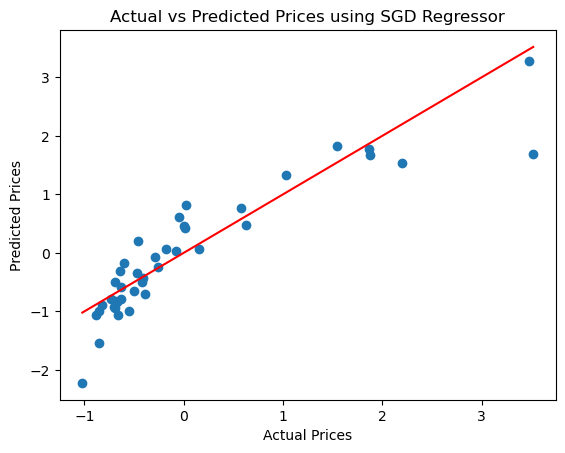

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red') # Perfect prediction line
plt.show()